# Exploratory Data Analysis

## Load Dataset

**1. Load a Dataset Directly from a GitHub Repository**

In [2]:
import pandas as pd
import numpy as np

url = (
    "https://raw.githubusercontent.com/wblakecannon/ames/"
    "refs/heads/master/data/housing.csv"
)

df = pd.read_csv(url)

print(df.shape)    # (2930, 83)
print(df.dtypes.value_counts())

(2930, 83)
str        43
int64      29
float64    11
Name: count, dtype: int64


**2. Load a Dataset Locally**

If the dataset is already downloaded to your machine:

In [3]:
import pandas as pd
import numpy as np

path = "../data/housing.csv"
df = pd.read_csv(path)

print(df.shape)    # (2930, 83)

(2930, 83)


### Column Name Standardisation
**Method 1 — Rename columns explicitly**

In [4]:
df = df.rename(columns={
    "Gr Liv Area": "GrLivArea",
    "Lot Area": "LotArea",
    "Total Bsmt SF": "TotalBsmtSF",
    "Overall Qual": "OverallQual",
    "Overall Cond": "OverallCond",
    "Year Built": "YearBuilt",
    "Year Remod/Add": "YearRemodAdd",
    "Bldg Type": "BldgType",
    "House Style": "HouseStyle",
    "Bedroom AbvGr": "BedroomAbvGr",
    "Full Bath": "FullBath",
    "Garage Cars": "GarageCars",
    "Garage Area": "GarageArea",
})

# Now your original code works exactly as written
key_cols = ["SalePrice", "GrLivArea", "LotArea", "TotalBsmtSF"]

**Method 2 — Strip spaces and slashes**

In [5]:
df.columns = (
    df.columns.str.strip()
    .str.replace(" ", "")
    .str.replace("/", "")
)

In [6]:
df = df.drop(columns=["Order", "PID"])
print(df.shape)    # (2930, 81)

(2930, 81)


## Descriptive Statistics

### Numeric summaries

In [7]:
numeric_cols = df.select_dtypes(include="number")
summary = numeric_cols.describe().T   # transpose for readability
print(summary[["count", "mean", "std", "min", "50%", "max"]].round(1).head(10))

               count     mean     std     min     50%       max
Unnamed:0     2930.0   1464.5   846.0     0.0  1464.5    2929.0
MSSubClass    2930.0     57.4    42.6    20.0    50.0     190.0
LotFrontage   2440.0     69.2    23.4    21.0    68.0     313.0
LotArea       2930.0  10147.9  7880.0  1300.0  9436.5  215245.0
OverallQual   2930.0      6.1     1.4     1.0     6.0      10.0
OverallCond   2930.0      5.6     1.1     1.0     5.0       9.0
YearBuilt     2930.0   1971.4    30.2  1872.0  1973.0    2010.0
YearRemodAdd  2930.0   1984.3    20.9  1950.0  1993.0    2010.0
MasVnrArea    2907.0    101.9   179.1     0.0     0.0    1600.0
BsmtFinSF1    2929.0    442.6   455.6     0.0   370.0    5644.0


### Measures of central tendency

In [8]:
sp = df["SalePrice"]

print(f"Mean:   ${sp.mean():,.0f}")
print(f"Median: ${sp.median():,.0f}")
print(f"Mode:   ${sp.mode()[0]:,.0f}")

Mean:   $180,796
Median: $160,000
Mode:   $135,000


### Measures of spread

In [9]:
print(f"Std Dev:  ${sp.std():,.0f}")
print(f"Variance: ${sp.var():,.0f}")
print(f"IQR:      ${sp.quantile(0.75) - sp.quantile(0.25):,.0f}")
print(f"Range:    ${sp.max() - sp.min():,.0f}")

Std Dev:  $79,887
Variance: $6,381,883,616
IQR:      $84,000
Range:    $742,211


### Skewness and kurtosis

In [10]:
key_cols = ["SalePrice", "GrLivArea", "LotArea", "TotalBsmtSF"]
shape_stats = pd.DataFrame({
    "Skewness": df[key_cols].skew().round(2),
    "Kurtosis": df[key_cols].kurt().round(2),
})
print(shape_stats)

             Skewness  Kurtosis
SalePrice        1.74      5.12
GrLivArea        1.27      4.14
LotArea         12.82    265.02
TotalBsmtSF      1.16      9.14


### Summarising categorical variables

In [11]:
cat_cols = ["Neighborhood", "BldgType", "HouseStyle"]

for col in cat_cols:
    print(f"\n--- {col} ---")
    freq = df[col].value_counts()
    pct  = df[col].value_counts(normalize=True).mul(100).round(1)
    print(pd.concat([freq, pct], axis=1, keys=["Count", "%"]).head(5))


--- Neighborhood ---
              Count     %
Neighborhood             
NAmes           443  15.1
CollgCr         267   9.1
OldTown         239   8.2
Edwards         194   6.6
Somerst         182   6.2

--- BldgType ---
          Count     %
BldgType             
1Fam       2425  82.8
TwnhsE      233   8.0
Duplex      109   3.7
Twnhs       101   3.4
2fmCon       62   2.1

--- HouseStyle ---
            Count     %
HouseStyle             
1Story       1481  50.5
2Story        873  29.8
1.5Fin        314  10.7
SLvl          128   4.4
SFoyer         83   2.8


## Distribution Analysis

### Histograms and bin width

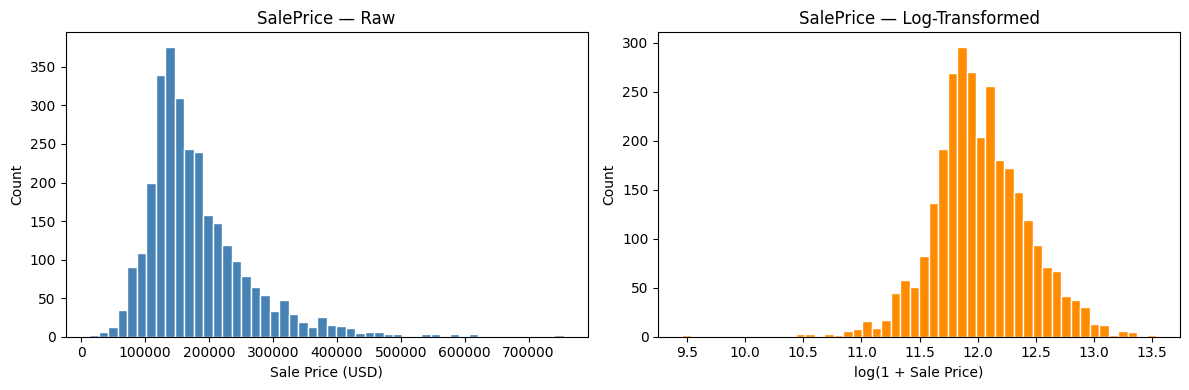

In [12]:
import matplotlib.pyplot as plt
import os

# create './outputs' to save plots 
os.makedirs("../outputs", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw sale price
axes[0].hist(df["SalePrice"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("SalePrice — Raw")
axes[0].set_xlabel("Sale Price (USD)")
axes[0].set_ylabel("Count")

# Log-transformed sale price
axes[1].hist(np.log1p(df["SalePrice"]), bins=50, color="darkorange", edgecolor="white")
axes[1].set_title("SalePrice — Log-Transformed")
axes[1].set_xlabel("log(1 + Sale Price)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("../outputs/saleprice_distribution.png", dpi=150)
plt.show()

### Kernel density estimation

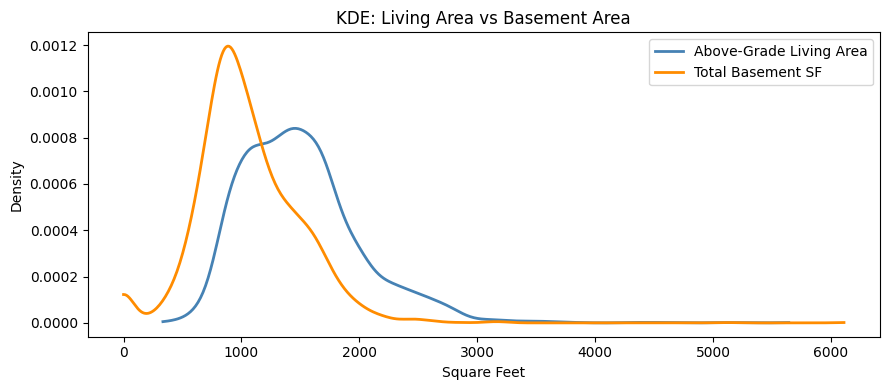

In [13]:
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(9, 4))

for col, color, label in [
    ("GrLivArea", "steelblue",  "Above-Grade Living Area"),
    ("TotalBsmtSF", "darkorange", "Total Basement SF"),
]:
    x = df[col].dropna()
    kde = gaussian_kde(x, bw_method="scott")
    xs  = np.linspace(x.min(), x.max(), 500)
    ax.plot(xs, kde(xs), label=label, color=color, linewidth=2)

ax.set_xlabel("Square Feet")
ax.set_ylabel("Density")
ax.set_title("KDE: Living Area vs Basement Area")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/kde_areas.png", dpi=150)
plt.show()

### Comparing distributions across groups

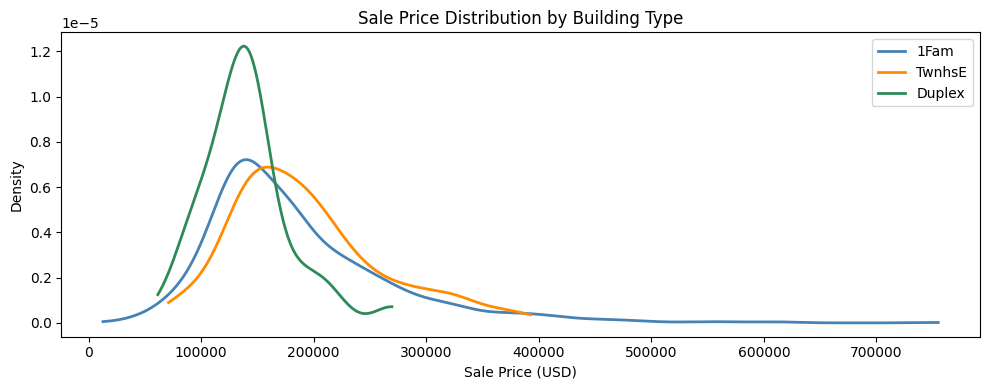

In [14]:
top_types = df["BldgType"].value_counts().head(3).index
colors    = ["steelblue", "darkorange", "seagreen"]

fig, ax = plt.subplots(figsize=(10, 4))

for btype, color in zip(top_types, colors):
    subset = df[df["BldgType"] == btype]["SalePrice"]
    kde    = gaussian_kde(subset, bw_method="scott")
    xs     = np.linspace(subset.min(), subset.max(), 500)
    ax.plot(xs, kde(xs), label=btype, color=color, linewidth=2)

ax.set_xlabel("Sale Price (USD)")
ax.set_ylabel("Density")
ax.set_title("Sale Price Distribution by Building Type")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/kde_by_bldgtype.png", dpi=150)
plt.show()

### Quantile–Quantile plots

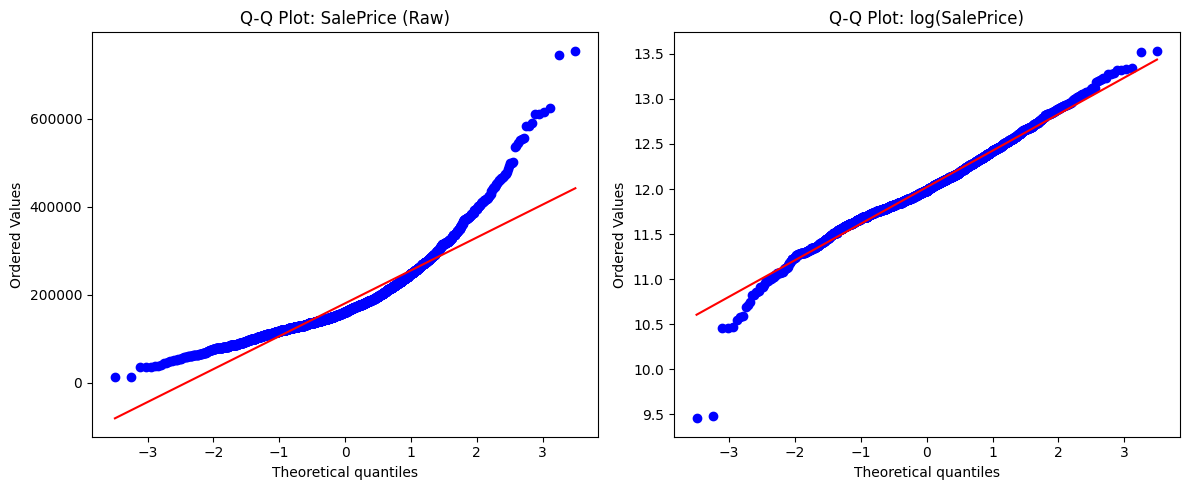

In [15]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Raw SalePrice
stats.probplot(df["SalePrice"], dist="norm", plot=axes[0])
axes[0].set_title("Q-Q Plot: SalePrice (Raw)")

# Log-transformed SalePrice
stats.probplot(np.log1p(df["SalePrice"]), dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot: log(SalePrice)")

plt.tight_layout()
plt.savefig("../outputs/qq_plots.png", dpi=150)
plt.show()

### Normality tests

In [16]:
from scipy.stats import shapiro, normaltest

for col in ["SalePrice", "GrLivArea", "OverallQual"]:
    stat_sw, p_sw  = shapiro(df[col].dropna().sample(500, random_state=42))
    stat_dp, p_dp  = normaltest(df[col].dropna())
    print(f"{col:20s}  Shapiro p={p_sw:.4f}   D'Agostino p={p_dp:.4f}")

SalePrice             Shapiro p=0.0000   D'Agostino p=0.0000
GrLivArea             Shapiro p=0.0000   D'Agostino p=0.0000
OverallQual           Shapiro p=0.0000   D'Agostino p=0.0001


### Box plots for distributional comparison

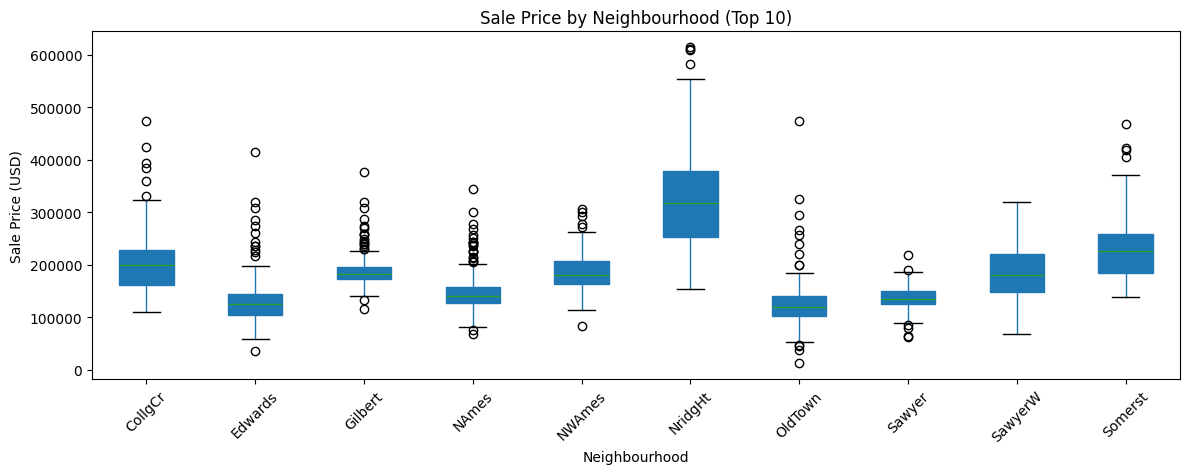

In [17]:
top_10_nb = df["Neighborhood"].value_counts().head(10).index
df_top    = df[df["Neighborhood"].isin(top_10_nb)]

fig, ax = plt.subplots(figsize=(12, 5))
df_top.boxplot(
    column="SalePrice",
    by="Neighborhood",
    ax=ax,
    grid=False,
    patch_artist=True,
)
ax.set_title("Sale Price by Neighbourhood (Top 10)")
ax.set_xlabel("Neighbourhood")
ax.set_ylabel("Sale Price (USD)")
plt.suptitle("")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/boxplot_neighborhood.png", dpi=150)
plt.show()

## Correlation Analysis

### Pearson correlation

In [18]:
# Correlation of numeric features with SalePrice
numeric_df = df.select_dtypes(include="number")
correlations = numeric_df.corr()["SalePrice"].drop("SalePrice")
top_corr = correlations.abs().sort_values(ascending=False).head(10)
print(top_corr.round(3))

OverallQual     0.799
GrLivArea       0.707
GarageCars      0.648
GarageArea      0.640
TotalBsmtSF     0.632
1stFlrSF        0.622
YearBuilt       0.558
FullBath        0.546
YearRemodAdd    0.533
GarageYrBlt     0.527
Name: SalePrice, dtype: float64


### Spearman rank correlation

In [19]:
from scipy.stats import spearmanr

cols_of_interest = ["SalePrice", "OverallQual", "GrLivArea", "LotArea", "YearBuilt"]

spearman_corrs = {}
for col in cols_of_interest[1:]:
    rho, pval = spearmanr(df["SalePrice"].dropna(), df[col].dropna())
    spearman_corrs[col] = {"Spearman r": round(rho, 3), "p-value": round(pval, 4)}

print(pd.DataFrame(spearman_corrs).T)

             Spearman r  p-value
OverallQual       0.809      0.0
GrLivArea         0.723      0.0
LotArea           0.429      0.0
YearBuilt         0.681      0.0


### The correlation matrix

In [20]:
key_features = [
    "SalePrice", "OverallQual", "GrLivArea", "TotalBsmtSF",
    "GarageCars", "YearBuilt", "FullBath", "Fireplaces"
]

corr_matrix = df[key_features].corr().round(2)
print(corr_matrix)

             SalePrice  OverallQual  GrLivArea  TotalBsmtSF  GarageCars  \
SalePrice         1.00         0.80       0.71         0.63        0.65   
OverallQual       0.80         1.00       0.57         0.55        0.60   
GrLivArea         0.71         0.57       1.00         0.44        0.49   
TotalBsmtSF       0.63         0.55       0.44         1.00        0.44   
GarageCars        0.65         0.60       0.49         0.44        1.00   
YearBuilt         0.56         0.60       0.24         0.41        0.54   
FullBath          0.55         0.52       0.63         0.32        0.48   
Fireplaces        0.47         0.39       0.45         0.33        0.32   

             YearBuilt  FullBath  Fireplaces  
SalePrice         0.56      0.55        0.47  
OverallQual       0.60      0.52        0.39  
GrLivArea         0.24      0.63        0.45  
TotalBsmtSF       0.41      0.32        0.33  
GarageCars        0.54      0.48        0.32  
YearBuilt         1.00      0.47        0.

### Visualising the correlation matrix as a heatmap

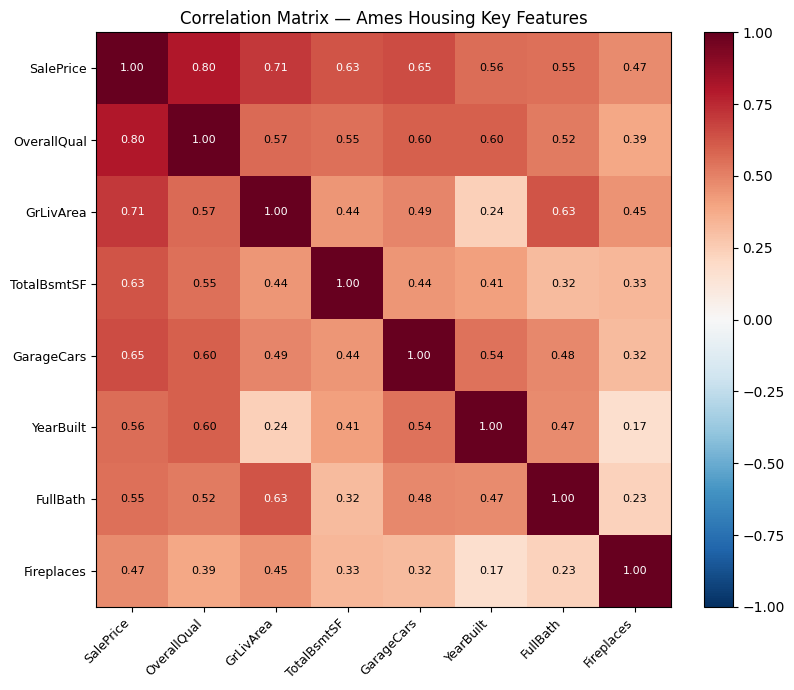

In [21]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(key_features)))
ax.set_yticks(range(len(key_features)))
ax.set_xticklabels(key_features, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(key_features, fontsize=9)

# Annotate each cell with the correlation value
for i in range(len(key_features)):
    for j in range(len(key_features)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}",
                ha="center", va="center", fontsize=8,
                color="white" if abs(corr_matrix.values[i, j]) > 0.6 else "black")

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Correlation Matrix — Ames Housing Key Features")
plt.tight_layout()
plt.savefig("../outputs/correlation_heatmap.png", dpi=150)
plt.show()

### Identifying multicollinearity

In [22]:
# Find all pairs with |r| > 0.80 (excluding self-correlations)
corr_full = df.select_dtypes(include="number").corr()
high_corr_pairs = (
    corr_full.where(
        np.triu(np.ones(corr_full.shape), k=1).astype(bool)
    )
    .stack()
    .reset_index()
)
high_corr_pairs.columns = ["Feature1", "Feature2", "Correlation"]
high_corr_pairs = high_corr_pairs[high_corr_pairs["Correlation"].abs() > 0.80]
print(high_corr_pairs.sort_values("Correlation", ascending=False).round(3))

         Feature1      Feature2  Correlation
1015   GarageCars    GarageArea        0.890
253     YearBuilt   GarageYrBlt        0.835
631     GrLivArea  TotRmsAbvGrd        0.808
469   TotalBsmtSF      1stFlrSF        0.801
36      Unnamed:0        YrSold       -0.976


## Detecting Patterns in Data

### Scatter plots and linear trends

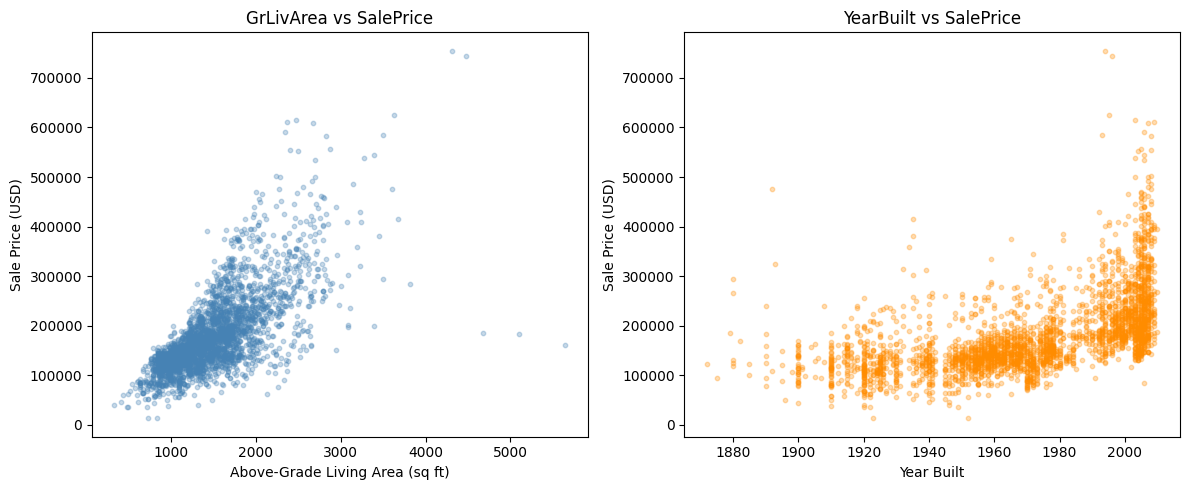

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# GrLivArea vs SalePrice
axes[0].scatter(df["GrLivArea"], df["SalePrice"],
                alpha=0.3, s=10, color="steelblue")
axes[0].set_xlabel("Above-Grade Living Area (sq ft)")
axes[0].set_ylabel("Sale Price (USD)")
axes[0].set_title("GrLivArea vs SalePrice")

# YearBuilt vs SalePrice
axes[1].scatter(df["YearBuilt"], df["SalePrice"],
                alpha=0.3, s=10, color="darkorange")
axes[1].set_xlabel("Year Built")
axes[1].set_ylabel("Sale Price (USD)")
axes[1].set_title("YearBuilt vs SalePrice")

plt.tight_layout()
plt.savefig("../outputs/scatter_plots.png", dpi=150)
plt.show()

### Group differences with box plots and violin plots

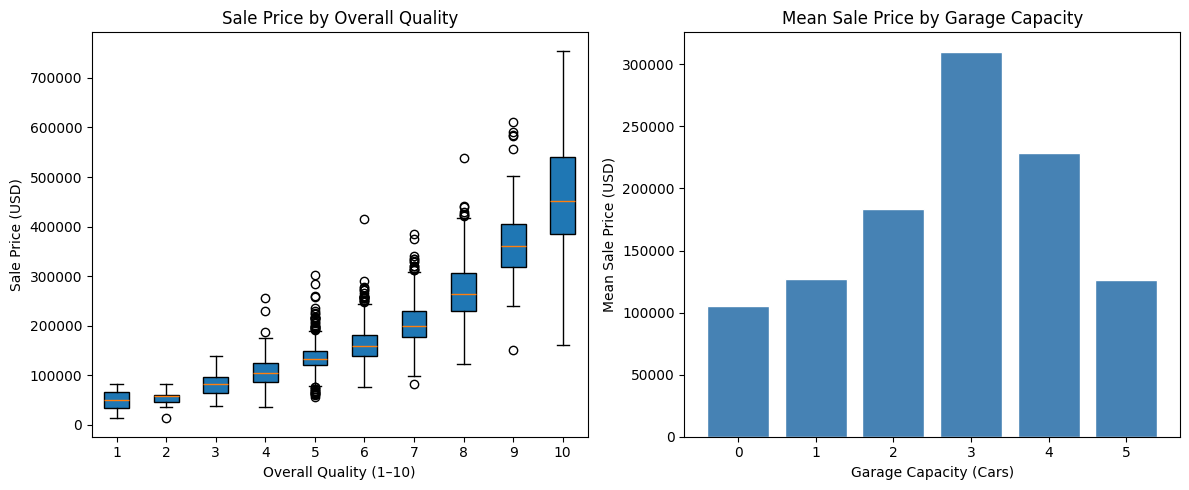

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box plot: SalePrice by OverallQual
quality_groups = [df[df["OverallQual"] == q]["SalePrice"].dropna()
                  for q in sorted(df["OverallQual"].unique())]
axes[0].boxplot(quality_groups,
                tick_labels=sorted(df["OverallQual"].unique()),
                patch_artist=True)
axes[0].set_xlabel("Overall Quality (1–10)")
axes[0].set_ylabel("Sale Price (USD)")
axes[0].set_title("Sale Price by Overall Quality")

# Mean sale price by number of garage cars
garage_means = df.groupby("GarageCars")["SalePrice"].mean().reset_index()
axes[1].bar(garage_means["GarageCars"], garage_means["SalePrice"],
            color="steelblue", edgecolor="white")
axes[1].set_xlabel("Garage Capacity (Cars)")
axes[1].set_ylabel("Mean Sale Price (USD)")
axes[1].set_title("Mean Sale Price by Garage Capacity")

plt.tight_layout()
plt.savefig("../outputs/group_patterns.png", dpi=150)
plt.show()

### Cross-tabulation of categorical variables

In [26]:
# BldgType × HouseStyle cross-tabulation (counts)
ct = pd.crosstab(df["BldgType"], df["HouseStyle"])
print(ct)

HouseStyle  1.5Fin  1.5Unf  1Story  2.5Fin  2.5Unf  2Story  SFoyer  SLvl
BldgType                                                                
1Fam           289      18    1222       7      18     703      48   120
2fmCon          19       1      16       1       4      18       2     1
Duplex           5       0      57       0       2      25      19     1
Twnhs            1       0      19       0       0      71       6     4
TwnhsE           0       0     167       0       0      56       8     2


In [27]:
ct_pct = pd.crosstab(df["BldgType"], df["HouseStyle"], normalize="index").round(2)
print(ct_pct[["1Story", "2Story", "1.5Fin"]])

HouseStyle  1Story  2Story  1.5Fin
BldgType                          
1Fam          0.50    0.29    0.12
2fmCon        0.26    0.29    0.31
Duplex        0.52    0.23    0.05
Twnhs         0.19    0.70    0.01
TwnhsE        0.72    0.24    0.00


### Pair plots for multivariate patterns

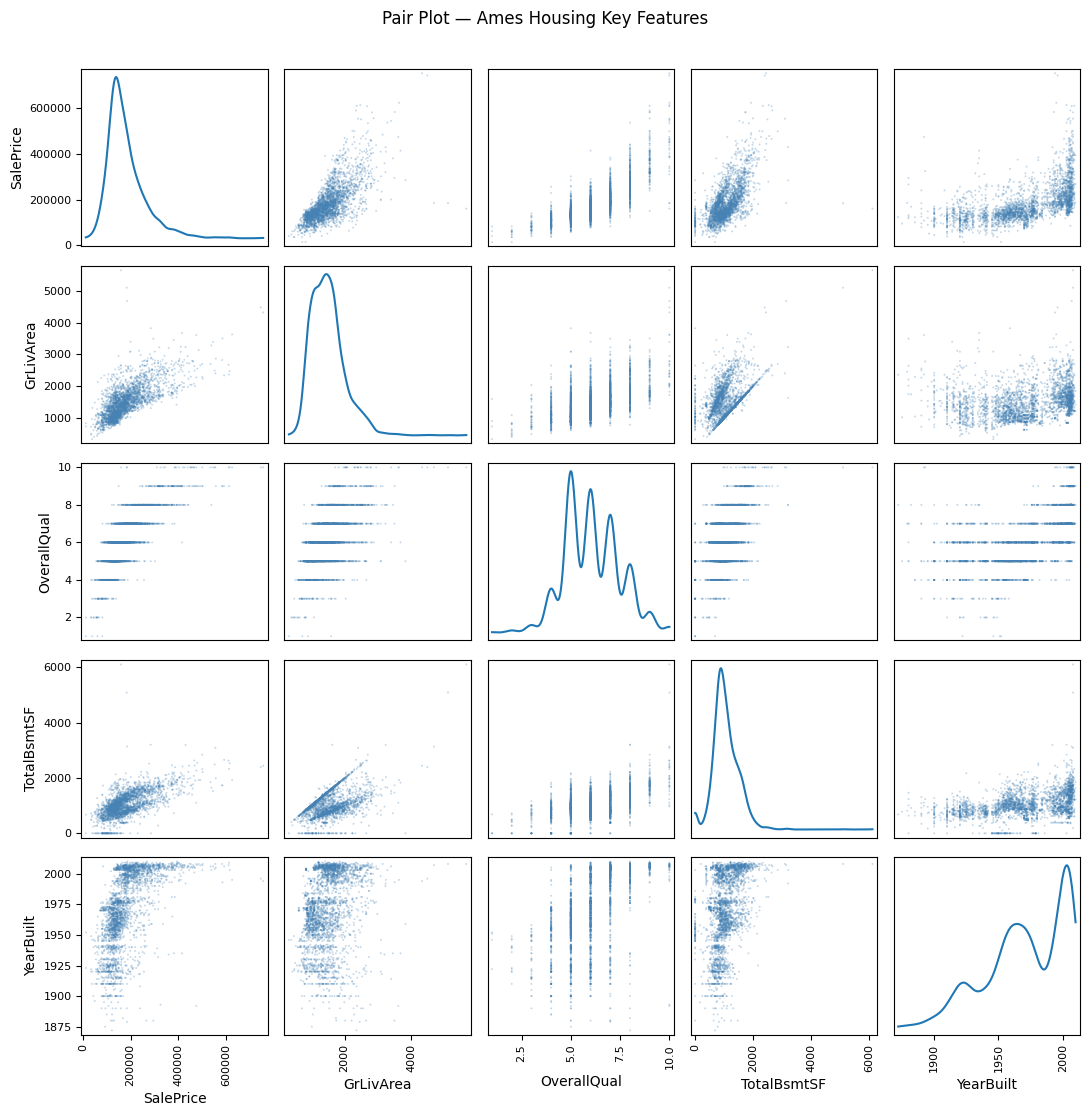

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

pair_cols = ["SalePrice", "GrLivArea", "OverallQual", "TotalBsmtSF", "YearBuilt"]
pair_df   = df[pair_cols].dropna()

pd.plotting.scatter_matrix(
    pair_df,
    figsize=(11, 11),
    diagonal="kde",
    alpha=0.3,
    s=8,
    color="steelblue",
)
plt.suptitle("Pair Plot — Ames Housing Key Features", y=1.01)
plt.tight_layout()
plt.savefig("../outputs/pair_plot.png", dpi=150)
plt.show()

### Groupby-driven pattern discovery

In [29]:
# Median SalePrice and count per neighbourhood, sorted by median price
nb_summary = (
    df.groupby("Neighborhood")["SalePrice"]
    .agg(["median", "mean", "count"])
    .rename(columns={"median": "Median", "mean": "Mean", "count": "Count"})
    .sort_values("Median", ascending=False)
)
print(nb_summary.round(0).head(8))

                Median      Mean  Count
Neighborhood                           
StoneBr       319000.0  324229.0     51
NridgHt       317750.0  322018.0    166
NoRidge       302000.0  330319.0     71
GrnHill       280000.0  280000.0      2
Veenker       250250.0  248315.0     24
Timber        232106.0  246600.0     72
Somerst       225500.0  229707.0    182
Crawfor       200624.0  207551.0    103


### Pivot tables for two-way pattern analysis

In [30]:
pivot = pd.pivot_table(
    df,
    values="SalePrice",
    index="OverallQual",
    columns="GarageCars",
    aggfunc="median",
).round(0)
print(pivot)

GarageCars        0.0       1.0       2.0       3.0       4.0       5.0
OverallQual                                                            
1             50150.0   81500.0   13100.0       NaN       NaN       NaN
2             60000.0   52062.0   33894.0       NaN       NaN       NaN
3             64750.0   91000.0   90200.0   93000.0  130000.0       NaN
4             88250.0  105000.0  116200.0  121500.0  145500.0       NaN
5            115000.0  128500.0  142776.0  149450.0  169500.0  126500.0
6            127500.0  132500.0  171712.0  194222.0  221250.0       NaN
7            130500.0  160000.0  197000.0  238900.0  267740.0       NaN
8            122000.0  161000.0  239000.0  290000.0       NaN       NaN
9                 NaN       NaN  307545.0  377500.0       NaN       NaN
10                NaN       NaN  325000.0  455000.0  460000.0       NaN
